###`Q-1:` Write a program to create an empty series.

In [16]:
# code here
import pandas as pd
import numpy as np

# Method 1:-
#series_null = pd.Series([np.nan,np.nan,np.nan])
#print(series_null)


# Method 2:-
s = pd.Series()
s

Series([], dtype: object)

###`Q-2:` Write a Pandas program to add, subtract, multiple and divide two Pandas Series.

In [17]:
# code here
s1 = pd.Series([1,11,12,13,14,15])
print(s1*2)
print(s1+2)
print(s1-2)
print(s1/2)
print(s1%2)

0     2
1    22
2    24
3    26
4    28
5    30
dtype: int64
0     3
1    13
2    14
3    15
4    16
5    17
dtype: int64
0    -1
1     9
2    10
3    11
4    12
5    13
dtype: int64
0    0.5
1    5.5
2    6.0
3    6.5
4    7.0
5    7.5
dtype: float64
0    1
1    1
2    0
3    1
4    0
5    1
dtype: int64


###`Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [18]:
# code here
s1 = pd.Series([2,4,6,8,10])
s2 = pd.Series([1,3,5,7,9])
print(s1==s2)
print(s1!=s2)

0    False
1    False
2    False
3    False
4    False
dtype: bool
0    True
1    True
2    True
3    True
4    True
dtype: bool


In [19]:
# Method 2:- using mannual loop!
s1 = pd.Series([2,4,6,8,10])
s2 = pd.Series([1,3,5,7,9])
result = []

for i in range(len(s1)):
    if s1[i] == s2[i]:
        result.append(True)
    else:
        result.append(False)
        
print(pd.Series(result))

0    False
1    False
2    False
3    False
4    False
dtype: bool


###`Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [20]:
# code here
import pandas as pd

def change_dtype(series, dtype):
    if dtype == 'float':
        return pd.to_numeric(series, errors='coerce').astype(float)
    elif dtype == 'int':
        return pd.to_numeric(series, errors='coerce').astype('Int64')
    else:
        return series.astype(dtype)

Download data - https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link
All Batsman runs series in IPL 2008 to 2022.

Below questions are based on this data.

###`Q-6` Find top 10 most run getter from the series.

In [21]:
# code here
import pandas as pd
runs = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/batsman_runs_series.csv').squeeze(True)

most_runs = runs.value_counts().head(10)
most_runs




batter          batsman_run
A Ashish Reddy  280            1
A Badoni        161            1
A Chandila      4              1
A Chopra        53             1
A Choudhary     25             1
A Dananjaya     4              1
A Flintoff      62             1
A Kumble        35             1
A Manohar       108            1
A Mishra        362            1
Name: count, dtype: int64

In [22]:
# Method 2:- using slicing and value counts
runs = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/batsman_runs_series.csv').squeeze(True)
most_runs = runs.value_counts()[0:10]
most_runs

batter          batsman_run
A Ashish Reddy  280            1
A Badoni        161            1
A Chandila      4              1
A Chopra        53             1
A Choudhary     25             1
A Dananjaya     4              1
A Flintoff      62             1
A Kumble        35             1
A Manohar       108            1
A Mishra        362            1
Name: count, dtype: int64

###`Q-7` No of players having runs above 3000

In [23]:
# code here
runs = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/batsman_runs_series.csv').squeeze(True)

most_runs = runs.value_counts() > 3000
most_runs

batter          batsman_run
A Ashish Reddy  280            False
A Badoni        161            False
A Chandila      4              False
A Chopra        53             False
A Choudhary     25             False
                               ...  
Yash Dayal      0              False
Yashpal Singh   47             False
Younis Khan     3              False
Yuvraj Singh    2754           False
Z Khan          117            False
Name: count, Length: 605, dtype: bool

###`Q-8` No of players having runs above mean value?

In [24]:
# code here
# Compute mean of actual runs -> Compare runs with mean ->Count how many are above mean
runs = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/batsman_runs_series.csv')['batsman_run']
runs = pd.to_numeric(runs, errors = 'coerce')
#1.
mean_runs = runs.mean()
#2. compare + add all the players run that sum of them are above mean value
count = (runs > mean_runs).sum()
print(count)

128


In [25]:
# all the Number of Players that are above the mean value
"""
    
runs = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/batsman_runs_series.csv')
runs['batsman_run'] = pd.to_numeric(runs['batter'], errors = 'coerce')
mean_runs = runs['batsman_run'].mean()
players_above = runs[runs['batsman_run'] > mean_runs]['batter'].unique()
print(players_above)
"""
import pandas as pd
df = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/batsman_runs_series.csv')
# Check columns
print(df.columns)
# Convert correct column
df['batsman_run'] = pd.to_numeric(df['batsman_run'], errors='coerce')  
# used in pd.to_numeric() & to_datetime() it try to convert everything into numbers and if conversion fails it make it NaN instead of throwing errors

# Drop NaN (VERY IMPORTANT)
df = df.dropna(subset=['batsman_run'])
# Mean
mean_runs = df['batsman_run'].mean()
print("Mean:", mean_runs)
# Filter
players_above = df[df['batsman_run'] > mean_runs]['batter'].unique()
print("Players above mean:", players_above)
print("Count:", len(players_above))


Index(['batter', 'batsman_run'], dtype='str')
Mean: 464.42809917355373
Players above mean: <StringArray>
[      'A Symonds',  'AB de Villiers',    'AC Gilchrist',      'AD Mathews',
      'AD Russell',        'AJ Finch',      'AK Markram',        'AM Nayar',
       'AM Rahane',        'AR Patel',
 ...
      'TM Dilshan',         'V Kohli',        'V Sehwag',       'V Shankar',
         'VR Iyer',         'WP Saha', 'Y Venugopal Rao',     'YBK Jaiswal',
       'YK Pathan',    'Yuvraj Singh']
Length: 128, dtype: str
Count: 128


Download data - https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv



###`Q-9`
    i. Read `items.csv` making `item_name` as index.
    ii. Show no of nan values
    ii. Item price is given in $, so convert it to rupees without currency symbol.
    iii. Make data type of newly made series as float.
    iv. Fill nan with mean of the series


How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

In [26]:
# code here
items= pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/items.csv')
items

# 1. Making items_mane as index value:-
items.set_index('item_name',inplace=True)


# 2.show no of nan values in dataset
items.isna().sum().sum()

# 3. item price is given in $ convert it into ruppees:-
# replace the symbol 
items['item_price'] = items['item_price'].str.replace('$', '', regex=False)
# convert string-> Numeric datatype
items['item_price'] = pd.to_numeric(items['item_price'], errors='coerce')
# Conversion
items['item_price'] = items['item_price'] * 83
print(items.head())


                                       item_price
item_name                                        
Chips and Fresh Tomato Salsa               198.37
Izze                                       281.37
Nantucket Nectar                           281.37
Chips and Tomatillo-Green Chili Salsa      198.37
Chicken Bowl                              1409.34


###`Q-10`:
    i. Find mean price
    ii. Find 30th and 6th percentile value
    iii. Plot Histogram on price with bin size 50
    iv. No of items price lies between [1000 to 2000]



Mean price: 619.4316141732284
6th percentile: 103.75
30th percentile: 369.35
Number of items with price between 1000–2000: 116


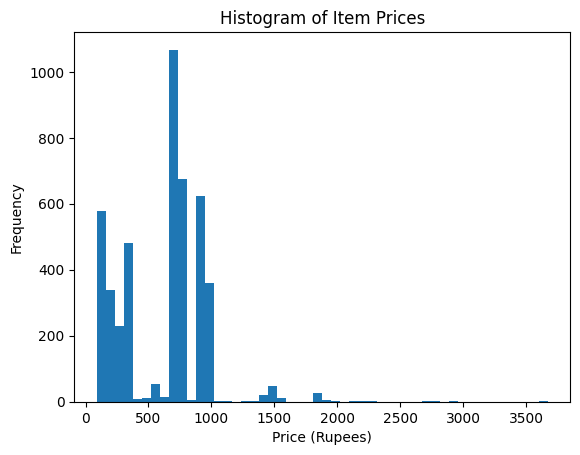

In [37]:

# code here

import pandas as pd
import matplotlib.pyplot as plt

items = pd.read_csv('/Volumes/VISHESH/Code/DSMP(GitRepo)/DSMP/Pandas/items.csv')

# Clean + convert
items['item_price'] = pd.to_numeric(
    items['item_price'].str.replace('$', '', regex=False),
    errors='coerce'
) * 83

# i. Mean
print("Mean price:", items['item_price'].mean())

# ii. Percentiles
print("6th percentile:", items['item_price'].quantile(0.06))
print("30th percentile:", items['item_price'].quantile(0.30))

# iv. Count
count_in_range = ((items['item_price'] >= 1000) & (items['item_price'] <= 2000)).sum()
print("Number of items with price between 1000–2000:", count_in_range)

# v. Histogram
plt.hist(items['item_price'], bins=50)
plt.xlabel('Price (Rupees)')
plt.ylabel('Frequency')
plt.title('Histogram of Item Prices')
plt.show()
